# Hypothesis

Thin notebook -- logic lives in `data/*.py` and `probe/*.py`. Follows `docs/decisions/0004-adaptation-hypothesis-demo-build.md` and `docs/notes/2026-08-02-build-plan.md` in stage order (S1-S10).

**Rule with no exceptions** (build plan S0): after every stage that touches data, open the images and look at them.

In [2]:
%cd /content
import os
if os.path.isdir("deepfake"):
    %cd deepfake
    !git pull
else:
    !git clone https://github.com/satyagalla/deepfake.git
    %cd deepfake

/content
/content/deepfake
Already up to date.


In [16]:
%pwd

'/content/deepfake'

In [ ]:
!pip install -q -r requirements.txt

In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
# A100 expected per build plan Environment section.

CUDA available: False
GPU: none


In [3]:
# Mount Drive as the durable store, but run everything off the VM's LOCAL disk.
#
# Drive is a network mount: measured 710 ms to open one image vs 1 ms locally.
# Extraction reads 21,299 images and writes 21,299 npz files, so pointing
# DATA_ROOT at Drive costs ~7.5 h; the same run from local disk is ~10 min.
# Drive stays the source of truth -- the cells below move data across as a
# single tar in each direction, because one large sequential transfer is cheap
# where 21k small ones are not.
#
# /content/data is WIPED when the runtime disconnects. Anything produced there
# is only safe once its "archive -> Drive" cell has run.
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/deepfake'
LOCAL_ROOT = '/content/data'
os.environ['DEEPFAKE_DATA_ROOT'] = LOCAL_ROOT  # must be set before any `import config`

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Stage data onto local disk

Run once per session, before anything else touches data.

First session copies `data_raw/` off Drive file-by-file, 32 at a time (~8-15 min), then leaves a `raw.tar` behind. Every later session restores from that tar in ~2-3 min -- one Drive open instead of 21,000. Also restores `probe/splits/`, and `probe.tar` if an earlier session archived it, so extraction and the fitted heads resume rather than restart.

In [18]:
import shutil, tarfile, time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

DRIVE, LOCAL = Path(DRIVE_ROOT), Path(LOCAL_ROOT)
(LOCAL / 'probe').mkdir(parents=True, exist_ok=True)
t = time.time()

raw_tar = DRIVE / 'raw.tar'
if raw_tar.exists():
    # Fast path: one Drive open instead of 21,000.
    print(f'restoring {raw_tar} ...')
    shutil.copy2(raw_tar, '/content/raw.tar')
    with tarfile.open('/content/raw.tar') as tf:
        tf.extractall(LOCAL)
elif (DRIVE / 'data_raw').is_dir():
    # Slow path, first session only. Drive latency is per-file and pipelines
    # well, so 32 concurrent copies turn ~4 h of serial opens into ~10 min.
    src = DRIVE / 'data_raw'
    files = [p for p in src.rglob('*') if p.is_file()]
    print(f'staging {len(files)} files, {sum(p.stat().st_size for p in files) / 1e9:.1f} GB ...')

    def _cp(p):
        d = LOCAL / 'data_raw' / p.relative_to(src)
        d.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(p, d)

    with ThreadPoolExecutor(32) as ex:
        list(ex.map(_cp, files))

    # Build the tar from LOCAL disk (1 ms/file) and write it to Drive once, so
    # this branch never runs again.
    print('building raw.tar ...')
    with tarfile.open('/content/raw.tar', 'w') as tf:
        tf.add(LOCAL / 'data_raw', arcname='data_raw')
    shutil.copy2('/content/raw.tar', raw_tar)
else:
    print('no raw data on Drive yet -- run S1/S2 below, then the archive cell')

# splits are two small files: always take Drive's copy
if (DRIVE / 'probe' / 'splits').is_dir():
    shutil.copytree(DRIVE / 'probe' / 'splits', LOCAL / 'probe' / 'splits', dirs_exist_ok=True)

# features/checkpoints/outputs from an earlier session, if any
probe_tar = DRIVE / 'probe.tar'
if probe_tar.exists():
    shutil.copy2(probe_tar, '/content/probe.tar')
    with tarfile.open('/content/probe.tar') as tf:
        tf.extractall(LOCAL / 'probe')
    print('restored probe.tar')

n = len(list((LOCAL / 'data_raw').rglob('*.jpg'))) if (LOCAL / 'data_raw').is_dir() else 0
splits = sorted(p.name for p in (LOCAL / 'probe' / 'splits').glob('*.json'))
print(f'\n{n} images on local disk in {(time.time() - t) / 60:.1f} min')
print('splits:', splits or 'MISSING -- run the probe.split cell below')

staging 49342 files, 8.1 GB ...
building raw.tar ...

40800 images on local disk in 22.8 min
splits: ['coco_ai_row_split.json', 'selfgen_split.json']


In [19]:
from google.colab import userdata
import os
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

## S1 -- Data (~45 min, highest risk, do first)

Fixes `0003`'s single highest-value finding: `data/download.py:68` discarded 5 of COCO_AI's 6 generator columns. Now takes all 7 (real + sd21/sdxl/sd3/sd35/dalle/midjourney), drops the person-caption filter (existed only for the face crop `0003` §4.1 already removed), and writes complete 7-way rows only -- a partial row would silently break the 1:1 pairing invariant (I2/I3).

In [ ]:
from data.download import test_sources

# No-download validation: HF schema (all 7 columns). skip_casia=True -- CASIA is the
# older face-filtered v1 pipeline's source (needs Kaggle credentials this notebook
# doesn't set up) and probe/ never reads it.
test_sources(skip_casia=True)

[COCO_AI] streaming 200 rows to check schema + complete-row hit rate (no files written)...
[COCO_AI] schema OK -- 200/200 sampled rows have all 7 columns (~100% hit rate)
[COCO_AI] OK

All sources OK -- safe to run the full download.


In [ ]:
from data.download import download_all

# Full download. n_pairs=3000 is the build-plan default; fall back to 1000 if this
# isn't done by the 60-minute abort condition (build plan S1) -- the N-shot claim
# does not need 3000 rows. skip_casia=True -- probe/ never reads CASIA (see above).
download_all(n_pairs=3000, skip_casia=True)

Streaming NasrinImp/COCO_AI (train split), collecting 3000 complete 7-column rows...


COCO_AI rows:   0%|          | 0/3000 [00:00<?, ?row/s]

HTTP Error 503 thrown while requesting GET https://huggingface.co/datasets/NasrinImp/COCO_AI/resolve/f30468bcfcfbfe5a38795218908eddd7c747d40e/data/train-00012-of-00013.parquet
Retrying in 1s [Retry 1/5].


COCO_AI: scanned 3000 rows (0 incomplete, missing >=1 of 7 columns), wrote 3000 complete rows to /content/deepfake/data_raw/coco_ai
[COCO_AI] done.


In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, "/content/deepfake")  # adjust to wherever the repo is cloned
from config import COCO_AI_COLUMNS, COCO_AI_RAW_DIR, DATA_ROOT

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"raw dir   = {COCO_AI_RAW_DIR}\n")

counts = {}
for key in COCO_AI_COLUMNS:
    d = COCO_AI_RAW_DIR / key
    counts[key] = len(list(d.glob("*.jpg"))) if d.exists() else 0
    print(f"{key:12s} {counts[key]}")

assert len(set(counts.values())) == 1, f"counts don't match: {counts}"

real_names = {p.name for p in (COCO_AI_RAW_DIR / "real").glob("*.jpg")}
for key in COCO_AI_COLUMNS:
    if key == "real":
        continue
    names = {p.name for p in (COCO_AI_RAW_DIR / key).glob("*.jpg")}
    assert names == real_names, f"{key} row_ids don't match real"

print(f"\nOK: {counts['real']} complete, paired rows across all {len(COCO_AI_COLUMNS)} columns.")

DATA_ROOT = /content/deepfake
raw dir   = /content/deepfake/data_raw/coco_ai

real         3000
sd21         3000
sdxl         3000
sd3          3000
sd35         3000
dalle        3000
midjourney   3000

OK: 3000 complete, paired rows across all 7 columns.


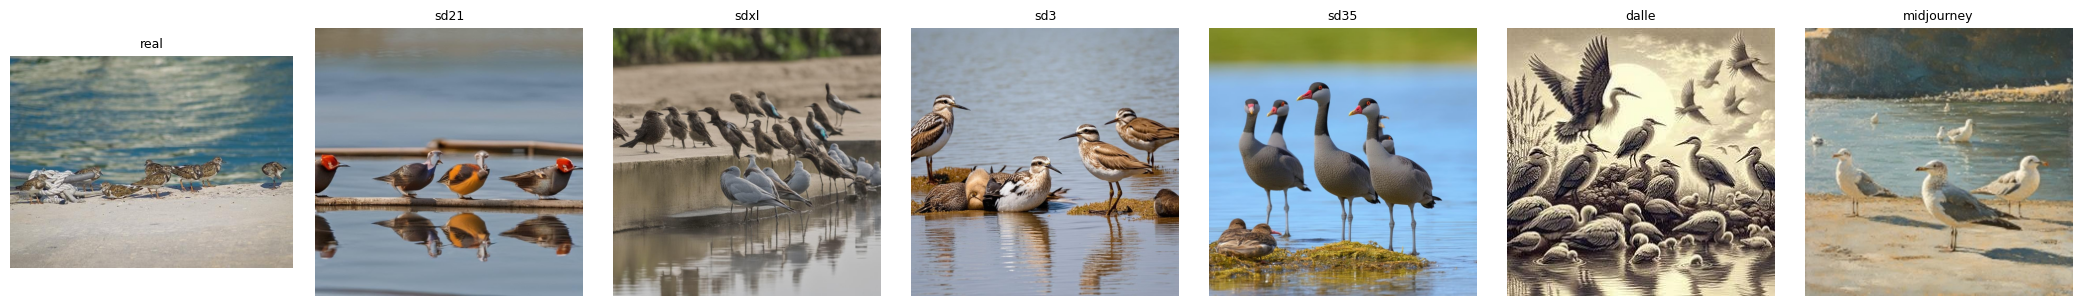

In [ ]:
# CHECKPOINT (build plan S1, no exceptions): open a few images per column and look
# at them. Confirm the real/fake pairing is intact for a sampled row.
from PIL import Image
from config import COCO_AI_RAW_DIR, COCO_AI_COLUMNS
import matplotlib.pyplot as plt

row_id = '00000'
fig, axes = plt.subplots(1, len(COCO_AI_COLUMNS), figsize=(3 * len(COCO_AI_COLUMNS), 3))
for ax, key in zip(axes, COCO_AI_COLUMNS):
    img_path = COCO_AI_RAW_DIR / key / f'{row_id}.jpg'
    ax.imshow(Image.open(img_path))
    ax.set_title(key, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Native resolution histogram per column (build plan S1 step 4) -- determines
# whether N=16 patches (0004 I1) is the right count.
!python data/resolution_stats.py

column            n    p10    p50    p90    min    max   nonoverlap@224(p50)
----------------------------------------------------------------------------
real           3000    363    428    480    190    640                   2.0
sd21           3000    768    768    768    768    768                   9.0
sdxl           3000   1024   1024   1024   1024   1024                  16.0
sd3            3000   1024   1024   1024   1024   1024                  16.0
sd35           3000   1024   1024   1024   1024   1024                  16.0
dalle          3000    270    270    270    270    351                   1.0
midjourney     3000    436    436    436    436    436                   1.0

real median short side / 224 = 1.91x -- comfortably above 1x: N=16 native patches has room to sample non-degenerately.


## S2 -- Self-generated N-shot pool (~45 min, manual generation step)

Generation itself is manual: Gemini + GPT-Image, COCO-caption prompted (content-domain matched) and off-domain prompted (E4), through both the API and the web UI (container control -- SynthID passes the naive container control by design, `bottlenecks.md` §4.2). This notebook only produces the prompts and organizes whatever lands in the intake folder.

In [ ]:
# Prints ~130 in-domain (COCO caption) + ~20-30 off-domain prompts to paste into
# Gemini/GPT-Image, both via the API and the web UI.
!python data/selfgen_prompts.py --indomain 130 --offdomain 20 --out selfgen_prompts.txt
print(open('selfgen_prompts.txt').read())

**Manual step:** generate images from the prompts above and drop them into
```
data_raw/selfgen_intake/<gemini|gptimage>/<indomain|offdomain>/<api|web>/*
```
e.g. `data_raw/selfgen_intake/gemini/indomain/web/img003.webp`. ~150-300 images total (build plan S2), ~20/generator off-domain, ~20/generator via the web UI. Then run the organizer cell below.

In [ ]:
# Re-saves everything at JPEG q95 (I4), builds the manifest, and prints the
# container-control check (does web UI actually differ from API in file format).
!python data/selfgen_organize.py

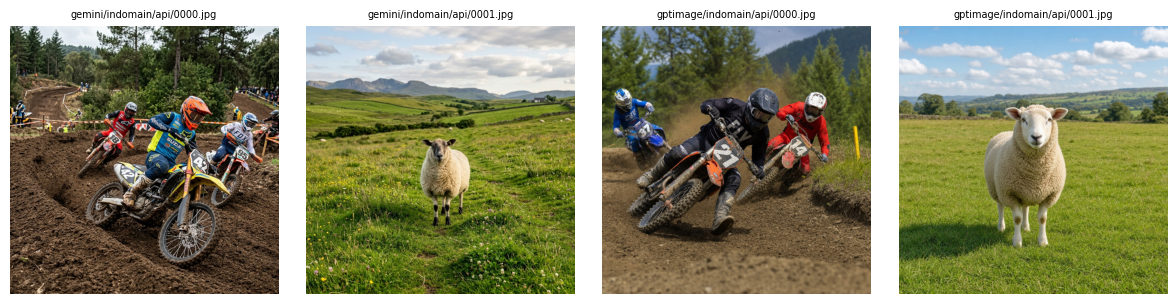

In [20]:
# CHECKPOINT: look at a few organized self-gen images per generator/domain.
from config import SELFGEN_RAW_DIR, SELFGEN_GENERATORS
import itertools

samples = []
for gen in SELFGEN_GENERATORS:
    for p in sorted((SELFGEN_RAW_DIR / gen).rglob('*.jpg'))[:2]:
        samples.append(p)
fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3))
for ax, p in zip(axes, samples):
    ax.imshow(Image.open(p))
    ax.set_title(p.relative_to(SELFGEN_RAW_DIR).as_posix(), fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# Archive raw data -> Drive as ONE tar. Run after S1/S2, and any time you add
# self-generated images: DATA_ROOT is local disk now, so raw images written by
# the cells above are wiped when the runtime disconnects.
# Reads local (1 ms/file), writes Drive once -- ~2-4 min.
import shutil, tarfile, time
from pathlib import Path

LOCAL, DRIVE = Path(LOCAL_ROOT), Path(DRIVE_ROOT)
t = time.time()
with tarfile.open('/content/raw.tar', 'w') as tf:
    tf.add(LOCAL / 'data_raw', arcname='data_raw')
shutil.copy2('/content/raw.tar', DRIVE / 'raw.tar')
size = (DRIVE / 'raw.tar').stat().st_size / 1e9
print(f'raw.tar -> Drive: {size:.1f} GB in {(time.time() - t) / 60:.1f} min')

raw.tar -> Drive: 8.2 GB in 0.7 min


## Row-level split (I2/I3/I7)

Splits COCO_AI at the row level (a row's real + all 6 fakes stay together), holds Midjourney out entirely (I7 -- never trained on at any N), and partitions the self-gen pool into an N-shot adaptation pool + a fixed eval slice per generator/domain.

In [22]:
!python -m probe.split

COCO_AI rows: 2550 train, 450 val, 3000 heldout (midjourney, 0-shot only)
COCO_AI images: 15300 train, 2700 val, 3000 heldout
selfgen[gemini][indomain]: pool=65 eval=64
selfgen[gemini][offdomain]: pool=10 eval=10
selfgen[gptimage][indomain]: pool=65 eval=65
selfgen[gptimage][offdomain]: pool=10 eval=10

Splits written to /content/data/probe/splits


## S3 -- Feature extraction (~10-15 min from local disk)

Frozen CLIP ViT-L/14 @224, fp16. N=16 native-resolution patches (I1, no resampling) + 1 whole-image resized view, CLIP's own normalization (I5), L2-normalized (I6). Second arm (`--arm standard`) is the ordinary resize+centre-crop pipeline -- UniversalFakeDetect's exact preprocessing, the reproducible control for E7.

Reads and writes both go to `/content/data`, staged above. The identical run against the Drive mount takes ~7.5 h: 710 ms per file open x 21,299 reads, plus 21,299 small npz writes back. Decode/crop/flatness run on DataLoader workers, and each batch is written as soon as it is encoded, so an interrupted run resumes instead of restarting.

In [23]:
!python -m probe.extract
!python -m probe.extract --arm standard

21299 image(s) queued for extraction (arm=patches, device=cuda, workers=8)
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
extract[native]: 100% 21299/21299 [06:46<00:00, 52.44img/s]
Wrote 21299 entries to /content/data/probe/features/index.csv
21299 image(s) queued for extraction (arm=standard, device=cuda, workers=8)
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: 

In [4]:
# CHECKPOINT: I1 assertion already runs inside extraction; spot-check feature norms are 1.0 (I6).
import numpy as np
from config import FEATURES_DIR
from probe.features import read_index

rows = read_index(FEATURES_DIR)[:5]
for r in rows:
    d = np.load(r.feature_path)
    print(r.key, 'patches:', d['patches'].shape, 'whole norm:', np.linalg.norm(d['whole']))

00001 patches: (16, 768) whole norm: 1.0
00001 patches: (16, 768) whole norm: 0.99999994
00001 patches: (16, 768) whole norm: 1.0
00001 patches: (16, 768) whole norm: 0.99999994
00001 patches: (16, 768) whole norm: 1.0000001


In [5]:
# Archive probe/ artifacts -> Drive as ONE tar. DO NOT SKIP: /content/data is
# wiped on disconnect. 21,299 individual npz writes to Drive would take hours;
# one ~1.1 GB sequential write takes ~1-2 min.
#
# Re-run this cell after S4 and S5 as well -- it picks up checkpoints/ and
# outputs/ as they appear, and the staging cell at the top restores whatever
# it finds here.
import shutil, tarfile, time
from pathlib import Path

LOCAL, DRIVE = Path(LOCAL_ROOT) / 'probe', Path(DRIVE_ROOT)
t = time.time()
saved = []
with tarfile.open('/content/probe.tar', 'w') as tf:
    for name in ('splits', 'features', 'features_standard', 'checkpoints', 'outputs'):
        if (LOCAL / name).is_dir():
            tf.add(LOCAL / name, arcname=name)
            saved.append(name)
shutil.copy2('/content/probe.tar', DRIVE / 'probe.tar')
size = (DRIVE / 'probe.tar').stat().st_size / 1e9
print(f"probe.tar -> Drive: {size:.2f} GB in {(time.time() - t) / 60:.1f} min")
print('contains:', ', '.join(saved) or 'NOTHING -- did extraction actually run?')

probe.tar -> Drive: 1.28 GB in 0.2 min
contains: splits, features, features_standard


## S4 -- Heads (~30 min)

Head A (binary, **no calibration stage** -- `0005` §3), Head B (generator ID), Mahalanobis OOD gate (pooled covariance, Ledoit-Wolf shrinkage), and the Spectral card's head -- all fit in seconds off the cached features. Saved to `config.PROBE_CHECKPOINT_DIR` for `probe/demo.py`.

In [6]:
!python -m probe.fit_production

Head A fitted on 15300 train rows (no calibration stage -- 0005 §3), saved as 'head_a'.
Head B fitted on 15450 rows (150 selfgen pool) -- classes: ['dalle', 'gemini', 'gptimage', 'real', 'sd21', 'sd3', 'sd35', 'sdxl'], saved as 'head_b'.
Mahalanobis gate fitted -- threshold=49.841, saved as 'mahalanobis_gate'.
Verdict cut points fitted on 450 real val images: {'likely_synthetic': 0.4702500518108711, 'weak_evidence': 0.15302957371904116} (budgets {'likely_synthetic': 0.01, 'weak_evidence': 0.1}), saved as 'verdict_thresholds'.
Spectral head fitted, saved as 'spectral_head'.


## S5 -- E1, the headline

N-shot adaptation curve: accuracy on gemini/gptimage vs N images from it, N in {0,5,10,20,30,50,100}, multiple random draws per N. **The knee is the finding, wherever it is** -- a curve with no knee falsifies the claim (0004 §9).

## S6 -- free experiments E2/E5/E6/E7, and E4

All come off the S3 cache at zero marginal GPU cost: E2 (Midjourney 0-shot), E5 (AUC, first measurement on this project), E6 (aggregator ablation), E7 (native patches vs standard resize), E4 (off-domain vs in-domain accuracy).

In [7]:
!python -m probe.experiments

E1[gemini]: eval set is 64 AI vs 450 real. AUC/TPR/FPR are prevalence-invariant and unaffected, but raw accuracy is not -- read `auc` and `balanced_accuracy`, never `accuracy` (0005 §5).
E1[gemini] N=100: pool only has 65 images, using 65.
E1[gemini] AUC:  [(0, 0.997), (5, 0.997), (10, 0.997), (20, 0.997), (30, 0.997), (50, 0.998), (100, 0.998)]
E1[gemini] bacc: [(0, 0.98), (5, 0.974), (10, 0.979), (20, 0.978), (30, 0.978), (50, 0.98), (100, 0.98)]
E1[gemini] 0-shot TPR=0.969 FPR=0.009 (n_ai=64, n_real=450)  -> first N reaching AUC 0.90: 0
E1[gptimage]: eval set is 65 AI vs 450 real. AUC/TPR/FPR are prevalence-invariant and unaffected, but raw accuracy is not -- read `auc` and `balanced_accuracy`, never `accuracy` (0005 §5).
E1[gptimage] N=100: pool only has 65 images, using 65.
E1[gptimage] AUC:  [(0, 0.999), (5, 0.999), (10, 0.999), (20, 0.999), (30, 0.999), (50, 0.999), (100, 0.999)]
E1[gptimage] bacc: [(0, 0.98), (5, 0.975), (10, 0.981), (20, 0.988), (30, 0.981), (50, 0.985), (100,

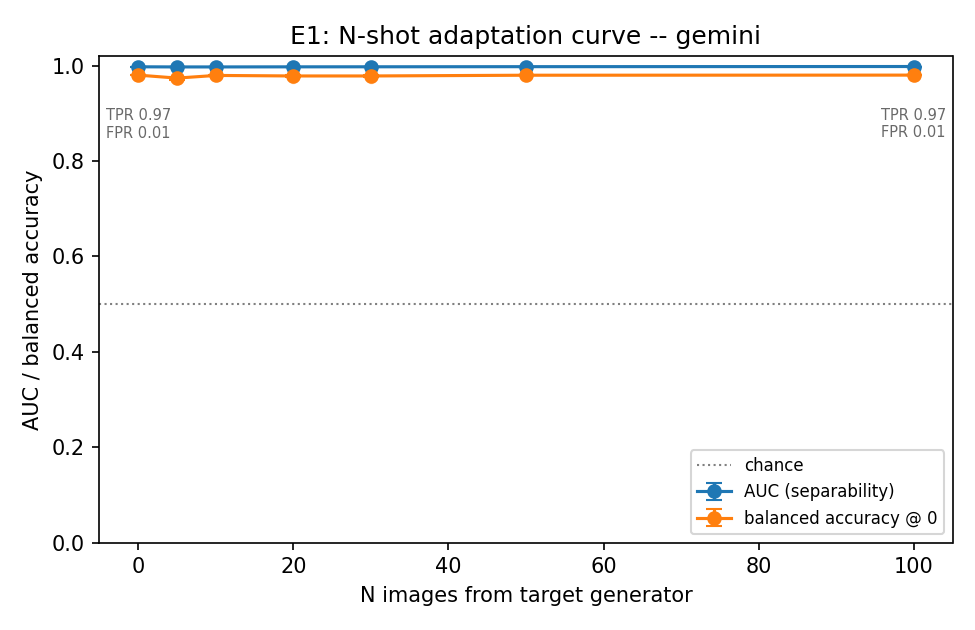

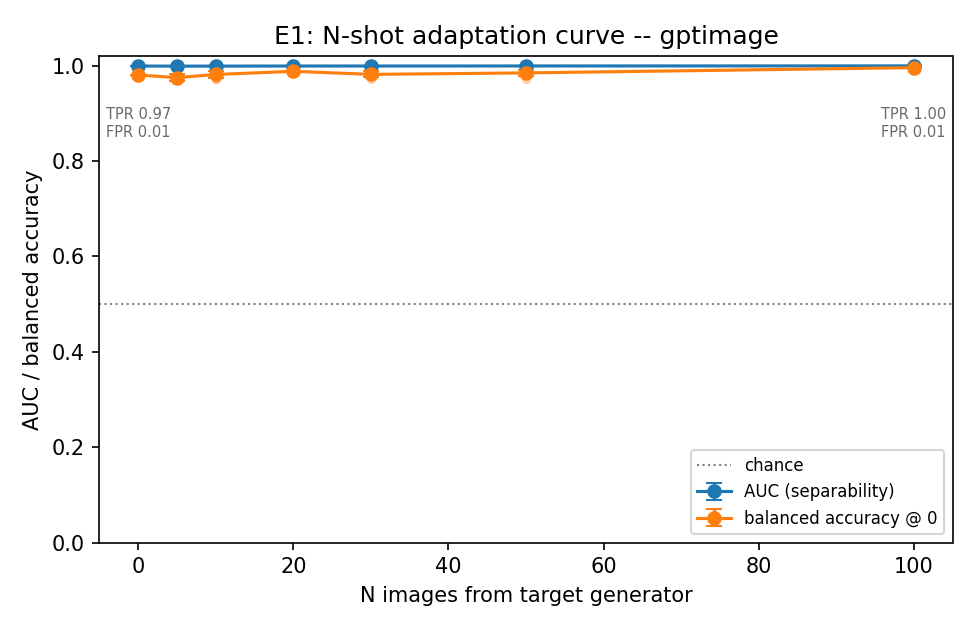

In [11]:
# E1 curves, rendered to PROBE_OUTPUTS_DIR during the run above.
from config import PROBE_OUTPUTS_DIR, SELFGEN_GENERATORS
from PIL import Image
from IPython.display import display
for gen in SELFGEN_GENERATORS:
    p = PROBE_OUTPUTS_DIR / f'e1_{gen}.png'
    if p.exists():
        display(Image.open(p))

## S9 -- E3, degradation ladder

Score each card across re-encode / rescale / re-render. A learned score (AI Model) that survives degradation identically to the provenance card (EXIF, which is stripped by any re-encode) is reading a watermark rather than a synthesis artifact. Gemini vs GPT-Image differ in watermarking policy -- the natural experiment.

Lowest priority in the cut order (build plan §3) -- skip this cell if time is short.

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
E3[gemini]: {
  "baseline": {
    "ai_model": 0.7530866455850274,
    "spectral": 0.7704786277859835
  },
  "reencode_q75": {
    "ai_model": 0.8682733329498487,
    "spectral": 0.587352376514329
  },
  "reencode_q50": {
    "ai_model": 0.8796700840522235,
    "spectral": 0.6896877699776887
  },
  "reencode_q30": {
    "ai_model": 0.8514841679781062,
    "spectral": 0.8476847198340934
  },
  "rescale_0.75": {
    "ai_model": 0.8224095722257869,
    "spectral": 0.9510602576992992
  },
  "rescale_0.5": {
    "ai_model": 0.8635597195058782,
    "spectral": 0.9702220270

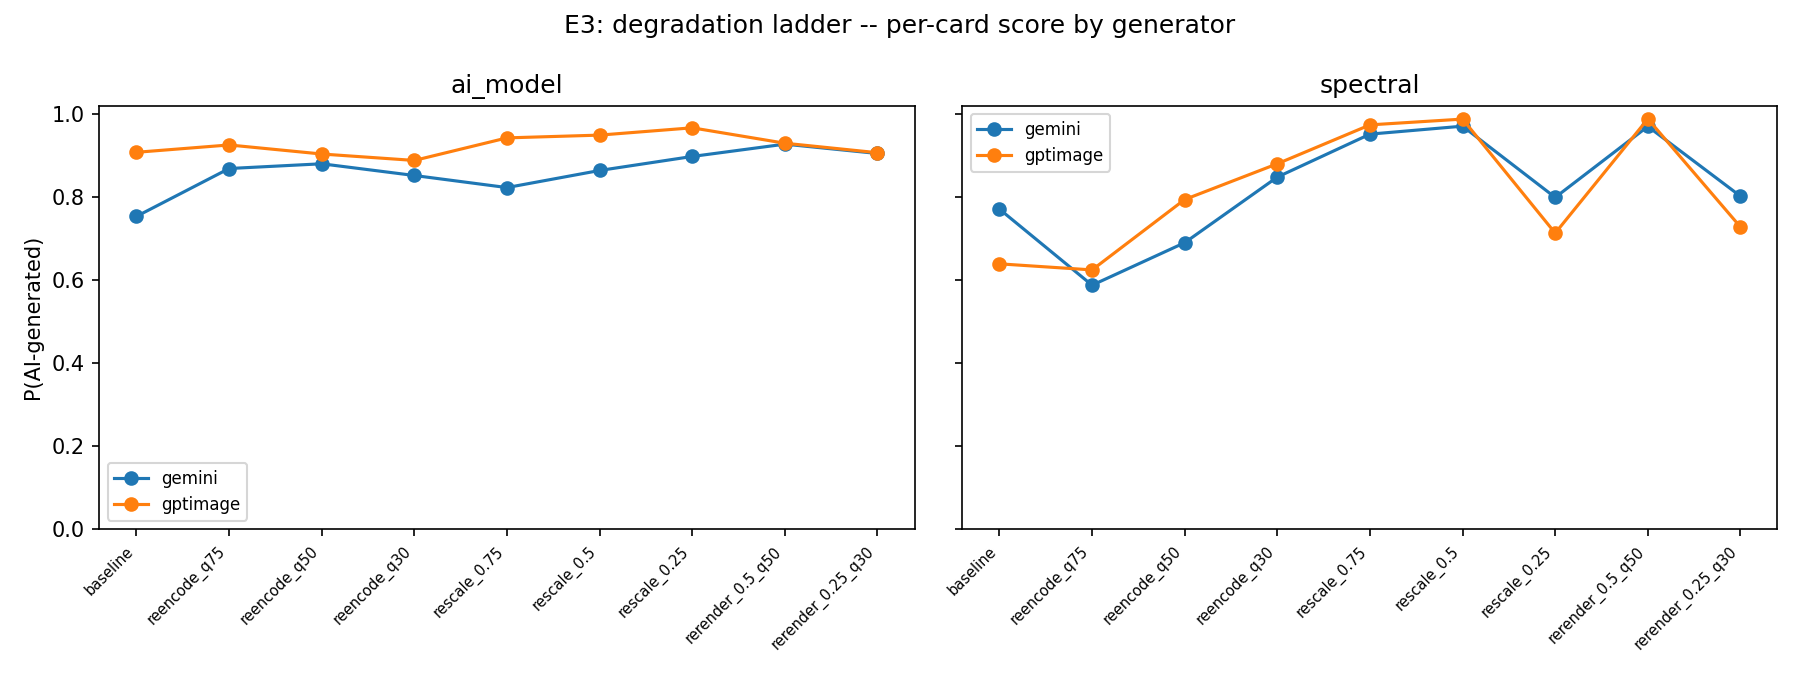

In [12]:
!python -m probe.degradation
from config import PROBE_OUTPUTS_DIR
display(Image.open(PROBE_OUTPUTS_DIR / 'e3_degradation.png'))

## S7 -- Evidence cards + fusion

Built inside `probe/cards.py` and exercised live by the demo below. Quick standalone check on one held-out image:

In [13]:
from pathlib import Path
from probe.extract import build_clip, featurize_single_image
from probe.cards import run_all_cards
from probe.heads import load
from config import HEAD_A_NAME, HEAD_B_NAME, GATE_NAME, SPECTRAL_HEAD_NAME, SELFGEN_RAW_DIR, SELFGEN_GENERATORS

model, preprocess_val = build_clip()
head_a, head_b, gate = load(HEAD_A_NAME), load(HEAD_B_NAME), load(GATE_NAME)
spectral_fitted = load(SPECTRAL_HEAD_NAME)

sample_path = next((SELFGEN_RAW_DIR / SELFGEN_GENERATORS[0]).rglob('*.jpg'))
sample_image = Image.open(sample_path).convert('RGB')
x_row = featurize_single_image(sample_image, model, preprocess_val)
cards, fusion = run_all_cards(sample_image, sample_path, x_row, head_a, head_b, gate, spectral_fitted)
for c in cards:
    print(f'{c.dimension:16s} score={c.score} silent={c.silent_because} {c.label}')
print('FUSION:', fusion.verdict, fusion.fused_score, 'reliability=', fusion.reliability)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


AI Model         score=0.779455849131103 silent=None generator=gptimage
Spectral         score=0.8612981767757848 silent=None radial FFT profile
EXIF             score=None silent=no EXIF or C2PA manifest found no metadata
Diffusion        score=None silent=not implemented -- documented stub not implemented
Temporal         score=None silent=input is a still image -- no temporal signal exists not applicable
Web Intelligence score=None silent=no reverse-image-search index available not implemented
FUSION: WEAK_EVIDENCE 0.8203770129534439 reliability= IN_DISTRIBUTION


## S8 -- Gradio demo

New path: no face crop, no MTCNN. Displays the fused score, verdict, all six cards, the abstention state, and E1's curve on screen with the live upload's score marked on it.

In [14]:
from probe.demo import build_app

demo = build_app()
demo.launch(share=True)  # share=True for the live interview demo

Loading CLIP backbone...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loading fitted heads (run `python -m probe.fit_production` first if this fails)...
Loaded FPR-derived verdict cut points: {'likely_synthetic': 0.4702500518108711, 'weak_evidence': 0.15302957371904116}
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ddc22473a5f86974c8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
